# Eddy Diffusivity on Pbar Surfaces

New notebook for estimating eddy diffusivity using the profiles with pbar as vertical coordinate

## Housekeeping

In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.path import Path
import matplotlib.colors as colors
import pandas as pd
import numpy as np
from importlib import reload
import cartopy.crs as ccrs
import cmocean.cm as cmo
import gsw
import scipy.ndimage as filter
import scipy.interpolate as interpolate
from flox.xarray import xarray_reduce
from xgcm.autogenerate import generate_grid_ds
from xgcm import Grid
from tqdm.notebook import tqdm
from scipy.ndimage import uniform_filter1d

In [2]:
import os
os.chdir('/home/amf2288/argo-intern/funcs')
import filt_funcs as ff
import density_funcs as df

In [3]:
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.titlesize']  = 18
plt.rcParams['axes.labelsize']  = 14
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14
plt.rcParams['legend.fontsize'] = 14

In [33]:
ds_pbar_grad = xr.open_dataset('/swot/SUM05/amf2288/ds_pbar_grad_bin.nc')
ds_pbar_grid = xr.open_dataset('/swot/SUM05/amf2288/ds_pbar_grid_var.nc')

In [34]:
ds_pbar_grid

<xarray.Dataset> Size: 1GB
Dimensions:          (PRESSURE_mean: 1001, LON: 120, LAT: 60, LON_left: 120,
                      LAT_left: 60)
Coordinates:
  * PRESSURE_mean    (PRESSURE_mean) int64 8kB 0 2 4 6 8 ... 1994 1996 1998 2000
  * LON              (LON) float64 960B -178.5 -175.5 -172.5 ... 175.5 178.5
  * LAT              (LAT) float64 480B -88.5 -85.5 -82.5 ... 82.5 85.5 88.5
  * LON_left         (LON_left) float64 960B -180.0 -177.0 ... 174.0 177.0
  * LAT_left         (LAT_left) float64 480B -90.0 -87.0 -84.0 ... 84.0 87.0
Data variables: (12/25)
    CT_sort          (PRESSURE_mean, LON, LAT) float64 58MB ...
    SA_sort          (PRESSURE_mean, LON, LAT) float64 58MB ...
    SPICE_sort       (PRESSURE_mean, LON, LAT) float64 58MB ...
    DENSITY          (PRESSURE_mean, LON, LAT) float64 58MB ...
    CT_sort_m        (PRESSURE_mean, LON, LAT) float64 58MB ...
    SA_sort_m        (PRESSURE_mean, LON, LAT) float64 58MB ...
    ...               ...
    CT_m_VPR         (PRESSURE_mean, LON, LAT) float64 58MB ...
    SA_m_VPR         (PRESSURE_mean, LON, LAT) float64 58MB ...
    SPICE_m_VPR      (PRESSURE_mean, LON, LAT) float64 58MB ...
    CT_meso_frac     (PRESSURE_mean, LON, LAT) float64 58MB ...
    SA_meso_frac     (PRESSURE_mean, LON, LAT) float64 58MB ...
    SPICE_meso_frac  (PRESSURE_mean, LON, LAT) float64 58MB ...

In [35]:
ds_pbar_grad

<xarray.Dataset> Size: 750MB
Dimensions:        (LON: 120, LAT: 60, PRESSURE_mean: 1001, LON_left: 120,
                    LAT_left: 60)
Coordinates:
  * LON            (LON) float64 960B -178.5 -175.5 -172.5 ... 172.5 175.5 178.5
  * LAT            (LAT) float64 480B -88.5 -85.5 -82.5 -79.5 ... 82.5 85.5 88.5
  * PRESSURE_mean  (PRESSURE_mean) int64 8kB 0 2 4 6 8 ... 1994 1996 1998 2000
  * LON_left       (LON_left) float64 960B -180.0 -177.0 -174.0 ... 174.0 177.0
  * LAT_left       (LAT_left) float64 480B -90.0 -87.0 -84.0 ... 81.0 84.0 87.0
Data variables: (12/14)
    CT_m_bin       (PRESSURE_mean, LON, LAT) float64 58MB ...
    SA_m_bin       (PRESSURE_mean, LON, LAT) float64 58MB ...
    SPICE_m_bin    (PRESSURE_mean, LON, LAT) float64 58MB ...
    DENSITY        (PRESSURE_mean, LON, LAT) float64 58MB ...
    dCT_m_dx       (PRESSURE_mean, LON, LAT) float64 58MB ...
    dCT_m_dy       (PRESSURE_mean, LON, LAT) float64 58MB ...
    ...             ...
    dSPICE_m_dx    (PRESSURE_mean, LON, LAT) float64 58MB ...
    dSPICE_m_dy    (PRESSURE_mean, LON, LAT) float64 58MB ...
    basin          (LAT, LON) float64 58kB ...
    dCT_m_dp       (PRESSURE_mean, LON, LAT) float64 58MB ...
    dSA_m_dp       (PRESSURE_mean, LON, LAT) float64 58MB ...
    dSPICE_m_dp    (PRESSURE_mean, LON, LAT) float64 58MB ...

In [36]:
K_rho_p = xr.open_dataarray('/swot/SUM05/amf2288/K_rho_filt_p.nc').drop_vars('Z').rename({'PRESSURE':'PRESSURE_mean'})
K_rho_p = K_rho_p.bfill(dim='PRESSURE_mean').ffill(dim='PRESSURE_mean')

## Calculate Diffusivity

In [37]:
ds_pbar_grad['K_e_CT'] = K_rho_p * ds_pbar_grid.CT_e_var/(ds_pbar_grad.dCT_m_dx**2 + ds_pbar_grad.dCT_m_dy**2)
ds_pbar_grad['K_e_SA'] = K_rho_p * ds_pbar_grid.SA_e_var/(ds_pbar_grad.dSA_m_dx**2 + ds_pbar_grad.dSA_m_dy**2)
ds_pbar_grad['K_e_SPICE'] = K_rho_p * ds_pbar_grid.SPICE_e_var/(ds_pbar_grad.dSPICE_m_dx**2 + ds_pbar_grad.dSPICE_m_dy**2)

In [38]:
ds_pbar_grad.to_netcdf('/swot/SUM05/amf2288/ds_pbar_grad_diff.nc')

## Evaluate Diff

In [95]:
C0 = float((ds_pbar_grad.dCT_m_dx**2 + ds_pbar_grad.dCT_m_dy**2).quantile(0.3))

In [96]:
lat_grad_clip = lat_grad.clip(min=C0)
K_e_CT_clip = K_rho_p * ds_pbar_grid.CT_e_var * (1/lat_grad_clip)

In [97]:
lat_grad = (ds_pbar_grad.dCT_m_dx**2 + ds_pbar_grad.dCT_m_dy**2)
lat_grad_tap = lat_grad / (lat_grad + C0)**2
K_e_CT_tap = K_rho_p * ds_pbar_grid.CT_e_var * lat_grad_tap

Text(0.5, 1.0, 'Tapered')

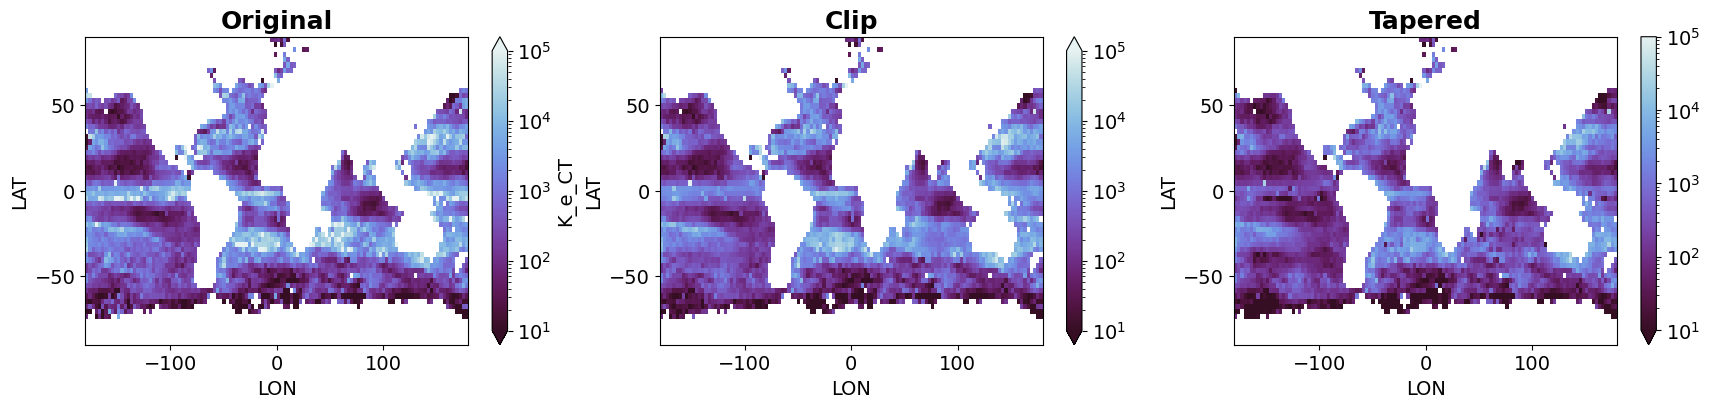

In [98]:
plt.figure(figsize=(21,4))
depth = 500


plt.subplot(131)
ds_pbar_grad.K_e_CT.sel(PRESSURE_mean=depth).plot(x='LON',y='LAT',cmap=cmo.dense_r, norm=colors.LogNorm(1e1,1e5))
plt.title('Original')

plt.subplot(132)
K_e_CT_clip.sel(PRESSURE_mean=depth).plot(x='LON',y='LAT',cmap=cmo.dense_r, norm=colors.LogNorm(1e1,1e5))
plt.title('Clip')

plt.subplot(133)
K_e_CT_tap.sel(PRESSURE_mean=depth).plot(x='LON',y='LAT',cmap=cmo.dense_r, norm=colors.LogNorm(1e1,1e5))
plt.title('Tapered')

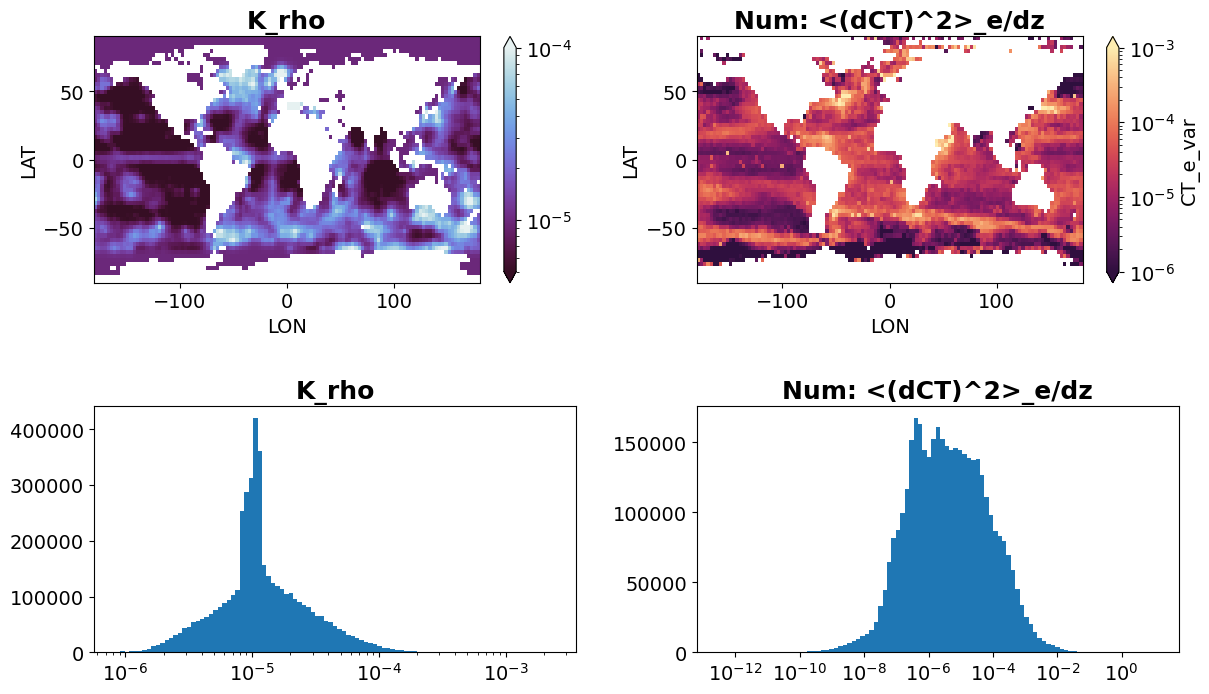

In [99]:
plt.figure(figsize=(14,8))
depth = 500

plt.subplot(221)
K_rho_p.sel(PRESSURE_mean=depth, method='nearest').plot(x='LON', y='LAT', cmap=cmo.dense_r, norm=colors.LogNorm(5e-6, 1e-4))
plt.title('K_rho')

plt.subplot(222)
ds_pbar_grid.CT_e_var.sel(PRESSURE_mean=depth, method='nearest').plot(x='LON',y='LAT', cmap=cmo.matter_r, norm=colors.LogNorm(1e-6,1e-3))
plt.title('Num: <(dCT)^2>_e/dz')

plt.subplot(223)
val = K_rho_p
plt.hist(val.values.flatten(), bins=np.logspace(np.log10(val.min()), np.log10(val.max()), 100))
plt.xscale("log")
plt.title('K_rho')

plt.subplot(224)
val = ds_pbar_grid.CT_e_var
plt.hist(val.values.flatten(), bins=np.logspace(np.log10(val.min()), np.log10(val.max()), 100))
plt.xscale("log")
plt.title('Num: <(dCT)^2>_e/dz')

plt.subplots_adjust(wspace=0.25, hspace=0.5)

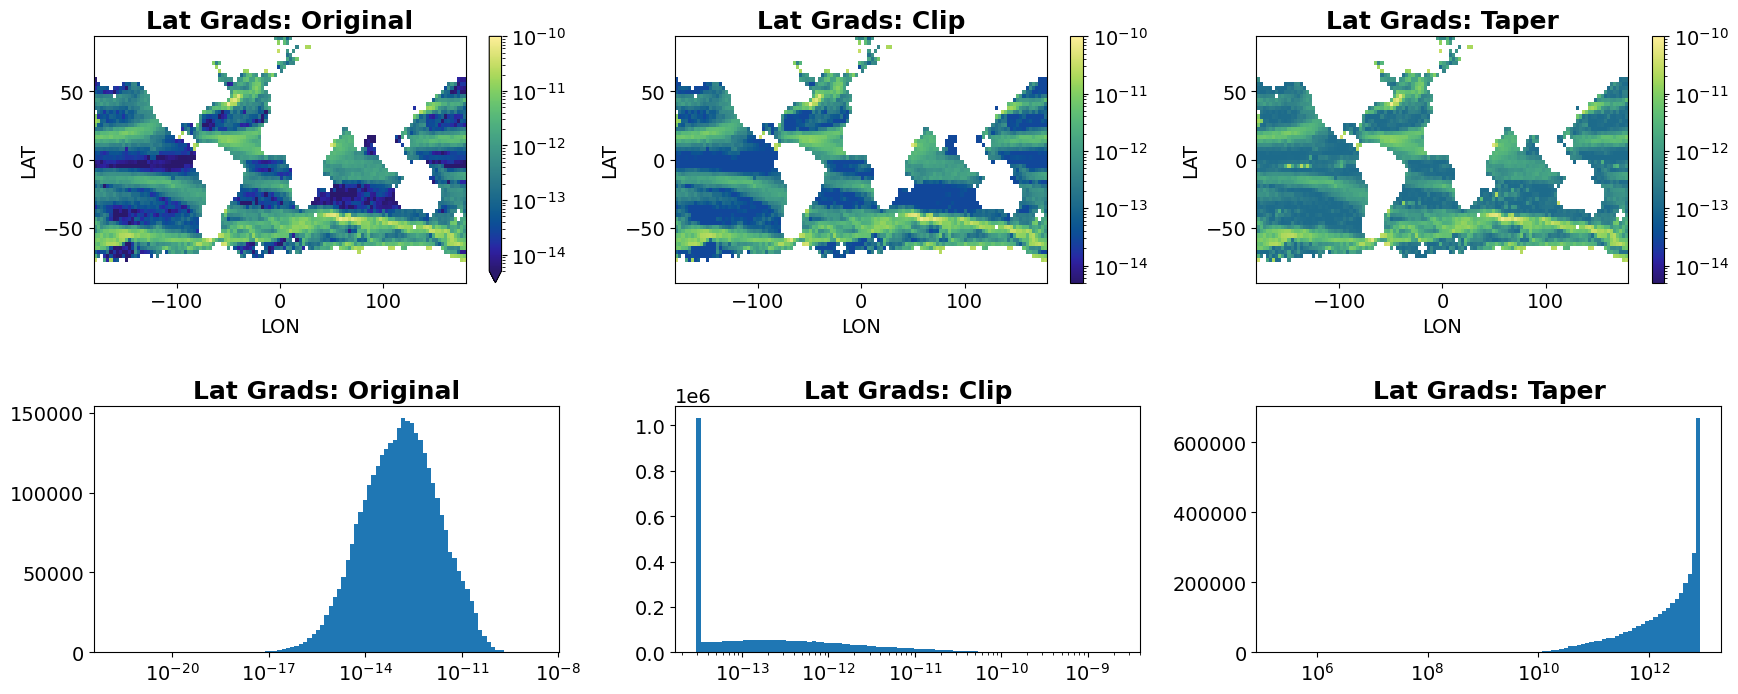

In [109]:
plt.figure(figsize=(21,8))

plt.subplot(231)
(ds_pbar_grad.dCT_m_dx**2 + ds_pbar_grad.dCT_m_dy**2).sel(PRESSURE_mean=depth, method='nearest').plot(x='LON', y='LAT', cmap=cmo.haline, norm=colors.LogNorm(5e-15, 1e-10))
plt.title('Lat Grads: Original')

plt.subplot(232)
lat_grad_clip.sel(PRESSURE_mean=depth, method='nearest').plot(x='LON', y='LAT', cmap=cmo.haline, norm=colors.LogNorm(5e-15, 1e-10))
plt.title('Lat Grads: Clip')

plt.subplot(233)
(1/lat_grad_tap).sel(PRESSURE_mean=depth, method='nearest').plot(x='LON', y='LAT', cmap=cmo.haline, norm=colors.LogNorm(5e-15, 1e-10))
plt.title('Lat Grads: Taper')

plt.subplot(234)
val = (ds_pbar_grad.dCT_m_dx**2 + ds_pbar_grad.dCT_m_dy**2)
plt.hist(val.values.flatten(), bins=np.logspace(np.log10(val.min()), np.log10(val.max()), 100))
plt.xscale("log")
plt.title('Lat Grads: Original')

plt.subplot(235)
val = lat_grad_clip
plt.hist(val.values.flatten(), bins=np.logspace(np.log10(val.min()), np.log10(val.max()), 100))
plt.xscale("log")
plt.title('Lat Grads: Clip')

plt.subplot(236)
val = lat_grad_tap
plt.hist(val.values.flatten(), bins=np.logspace(np.log10(val.min()), np.log10(val.max()), 100))
plt.xscale("log")
plt.title('Lat Grads: Taper')

plt.subplots_adjust(wspace=0.25, hspace=0.5)

Text(0.5, 1.0, 'Tapered')

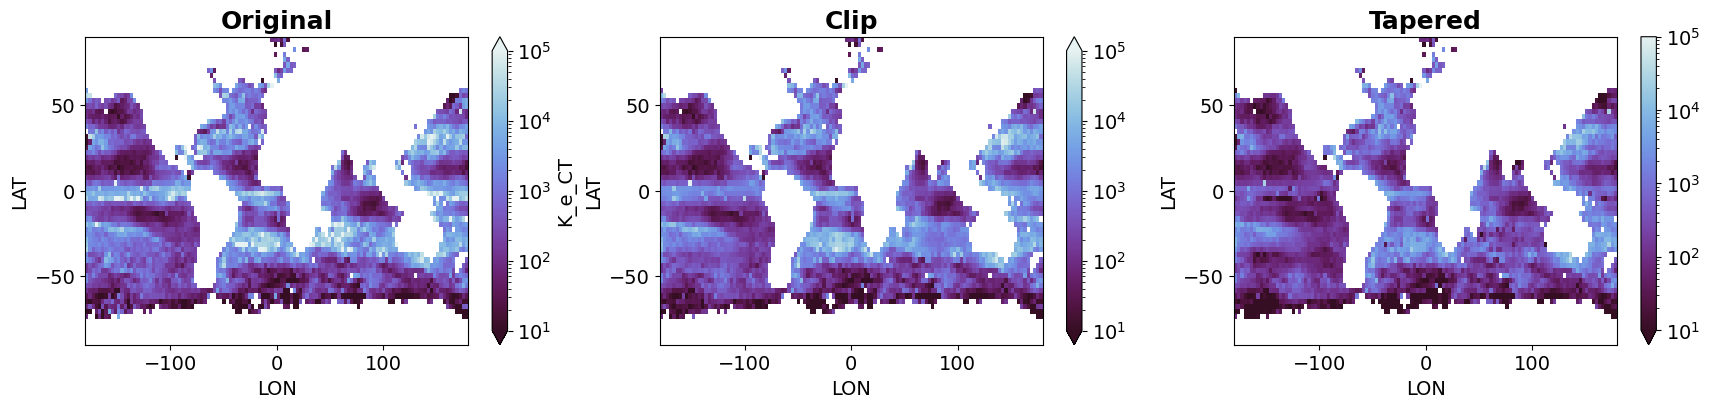

In [110]:
plt.figure(figsize=(21,4))
depth = 500


plt.subplot(131)
ds_pbar_grad.K_e_CT.sel(PRESSURE_mean=depth).plot(x='LON',y='LAT',cmap=cmo.dense_r, norm=colors.LogNorm(1e1,1e5))
plt.title('Original')

plt.subplot(132)
K_e_CT_clip.sel(PRESSURE_mean=depth).plot(x='LON',y='LAT',cmap=cmo.dense_r, norm=colors.LogNorm(1e1,1e5))
plt.title('Clip')

plt.subplot(133)
K_e_CT_tap.sel(PRESSURE_mean=depth).plot(x='LON',y='LAT',cmap=cmo.dense_r, norm=colors.LogNorm(1e1,1e5))
plt.title('Tapered')